<a href="https://colab.research.google.com/github/J4m331/COMP3608-IS-Project/blob/Create-Decision-Tree-Folder/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 35.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [13]:
#Dataset1/ df1 is the combination of 2 datasets from 2024
url1 = "https://raw.githubusercontent.com/J4m331/COMP3608-IS-Project/refs/heads/Create-Decision-Tree-Folder/data/vgData2024.csv"
Df1 = pd.read_csv(url1, header=0)

url2 = "https://raw.githubusercontent.com/J4m331/COMP3608-IS-Project/refs/heads/main/data/vgData2026.csv"
Df2 = pd.read_csv(url2, header=0)

In [14]:
Columns_needed= ["Name","Publisher","Platform","Genre","Release_Year","NA_Sales","EU_Sales","JP_Sales","Other_Sales"]

Df1 = Df1[Columns_needed]
Df2 = Df2[Columns_needed]


In [15]:
Df1= Df1.drop_duplicates(subset='Name')
Df2= Df2.drop_duplicates(subset='Name')

#Fix release year
Df1['Release_Year'] = pd.to_datetime(Df1['Release_Year'], errors='coerce').dt.year
Df2['Release_Year'] = pd.to_datetime(Df2['Release_Year'], errors='coerce').dt.year

#Fill missing years with median
Df1['Release_Year'] = Df1['Release_Year'].fillna(Df1['Release_Year'].median())
Df2['Release_Year'] = Df2['Release_Year'].fillna(Df2['Release_Year'].median())

# Convert to integer
Df1['Release_Year'] = Df1['Release_Year'].astype(int)
Df2['Release_Year'] = Df2['Release_Year'].astype(int)

Df1.head()



,Name,Publisher,Platform,Genre,Release_Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,'98 Koshien,Magical Company,PS,Sports,1998,0.15,0.10,0.12,0.03
1,.hack//G.U. Vol.1//Rebirth,Namco Bandai Games,PS2,Role-Playing,2008,0.00,0.00,0.17,0.00
2,.hack//G.U. Vol.2//Reminisce,Namco Bandai Games,PS2,Role-Playing,2008,0.11,0.09,0.00,0.03
3,.hack//G.U. Vol.2//Reminisce (jp sales),Namco Bandai Games,PS2,Role-Playing,2008,0.00,0.00,0.16,0.00
4,.hack//G.U. Vol.3//Redemption,Namco Bandai Games,PS2,Role-Playing,2008,0.00,0.00,0.17,0.00


In [16]:
Df2.head()

,Name,Publisher,Platform,Genre,Release_Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,'98 Koshien,Magical Company,PS,Sports,1970,0.15,0.10,0.12,0.03
1,.hack//G.U. Vol.1//Rebirth,Namco Bandai Games,PS2,Role-Playing,1970,0.00,0.00,0.17,0.00
2,.hack//G.U. Vol.2//Reminisce,Namco Bandai Games,PS2,Role-Playing,1970,0.11,0.09,0.00,0.03
3,.hack//G.U. Vol.2//Reminisce (jp sales),Namco Bandai Games,PS2,Role-Playing,1970,0.00,0.00,0.16,0.00
4,.hack//G.U. Vol.3//Redemption,Namco Bandai Games,PS2,Role-Playing,1970,0.00,0.00,0.17,0.00


In [18]:
#Calculate total sales
Df1['Total_Sales'] = (Df1['NA_Sales']+  Df1['EU_Sales']+Df1['JP_Sales']+Df1['Other_Sales'])
Df2['Total_Sales'] = (Df2['NA_Sales']+  Df2['EU_Sales']+Df2['JP_Sales']+Df2['Other_Sales'])


In [20]:
#Create sales category
low_threshold1 = Df1['Total_Sales'].quantile(0.33)
high_threshold1 = Df1['Total_Sales'].quantile(0.66)

low_threshold2 = Df2['Total_Sales'].quantile(0.33)
high_threshold2 = Df2['Total_Sales'].quantile(0.66)

def classify_sales1(x):
    if x <= low_threshold1:
        return 'Low'
    elif x <= high_threshold1:
        return 'Medium'
    else:
        return 'High'


def classify_sales2(x):
    if x <= low_threshold2:
        return 'Low'
    elif x <= high_threshold2:
        return 'Medium'
    else:
        return 'High'


Df1['Sales_Category'] = Df1['Total_Sales'].apply(classify_sales1)
Df2['Sales_Category'] = Df2['Total_Sales'].apply(classify_sales2)

In [21]:
#Encode categorical variables

le_genre = LabelEncoder()
le_platform = LabelEncoder()
le_publisher = LabelEncoder()
le_target = LabelEncoder()

Df1['Genre_enc'] = le_genre.fit_transform(Df1['Genre'])
Df1['Platform_enc'] = le_platform.fit_transform(Df1['Platform'])
Df1['Publisher_enc'] = le_publisher.fit_transform(Df1['Publisher'])
Df1['Sales_Category_enc'] = le_target.fit_transform(Df1['Sales_Category'])

Df2['Genre_enc'] = le_genre.transform(Df2['Genre'])
Df2['Platform_enc'] = le_platform.transform(Df2['Platform'])
Df2['Publisher_enc'] = le_publisher.transform(Df2['Publisher'])
Df2['Sales_Category_enc'] = le_target.transform(Df2['Sales_Category'])

In [23]:
#Features and target
X1 = Df1[['Genre_enc', 'Platform_enc', 'Publisher_enc', 'Release_Year']]
Y2 = Df1['Sales_Category_enc']

X2 = Df2[['Genre_enc', 'Platform_enc', 'Publisher_enc', 'Release_Year']]
Y2 = Df2['Sales_Category_enc']

In [24]:
X1_train, X1_test, Y1_train, Y1_test= train_test_split(X1, Y2, test_size=0.3, random_state=100)
X2_train, X2_test, Y2_train, Y2_test= train_test_split(X2, Y2, test_size=0.3, random_state=100)


In [26]:
model2 = DecisionTreeClassifier(max_depth = 5, random_state = 100)
model2.fit(X2_train, Y2_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [25]:
model1 = DecisionTreeClassifier(max_depth = 5, random_state = 100)
model1.fit(X1_train, Y1_train)



,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [41]:
print("Df1 metrics")
y1_pred = model1.predict(X1_test)
accuracy1 = accuracy_score(Y1_test, y1_pred)
print(f"Accuracy:{accuracy1:.4f}")
print("\nClssification Report:\n",classification_report(Y1_test, y1_pred))
print("\nConfusion Matrix:\n",confusion_matrix(Y1_test, y1_pred))

print("\n")

print("Df2 metrics")
y2_pred = model2.predict(X2_test)
accuracy2 = accuracy_score(Y2_test, y2_pred)
print(f"Accuracy:{accuracy2:.4f}")
print("\nClssification Report:\n",classification_report(Y2_test, y2_pred))
print("\nConfusion Matrix:\n",confusion_matrix(Y2_test, y2_pred))

Df1 metrics
Accuracy:0.4454

Clssification Report:
               precision    recall  f1-score   support

           0       0.53      0.34      0.42      1122
           1       0.51      0.46      0.48      1191
           2       0.36      0.54      0.43      1073

    accuracy                           0.45      3386
   macro avg       0.47      0.45      0.44      3386
weighted avg       0.47      0.45      0.45      3386


Confusion Matrix:
 [[386 239 497]
 [134 544 513]
 [215 280 578]]


Df2 metrics
Accuracy:0.4663

Clssification Report:
               precision    recall  f1-score   support

           0       0.49      0.57      0.53      1122
           1       0.50      0.55      0.53      1191
           2       0.36      0.26      0.30      1073

    accuracy                           0.47      3386
   macro avg       0.45      0.46      0.45      3386
weighted avg       0.45      0.47      0.46      3386


Confusion Matrix:
 [[639 234 249]
 [276 658 257]
 [379 412 282]]


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy1 = accuracy_score(Y1_test, y1_pred)
precision1 = precision_score(Y1_test, y1_pred, average='weighted')
recall1 = recall_score(Y1_test, y1_pred, average='weighted')
f1score1 = f1_score(Y1_test, y1_pred, average='weighted')

accuracy2 = accuracy_score(Y2_test, y2_pred)
precision2 = precision_score(Y2_test, y2_pred, average='weighted')
recall2 = recall_score(Y2_test, y2_pred, average='weighted')
f1score2 = f1_score(Y2_test, y2_pred, average='weighted')

results = pd.DataFrame({
    'Dataset': ['Dataset1', 'Dataset2'],
    'Accuracy': [accuracy1, accuracy2],
    'Precision': [precision1, precision2],
    'Recall': [recall1, recall2],
    'F1 Score': [f1score1, f1score2]
})

print(results)

    Dataset  Accuracy  Precision    Recall  F1 Score
0  Dataset1  0.445363   0.469373  0.445363  0.445207
1  Dataset2  0.466332   0.454529  0.466332  0.456850


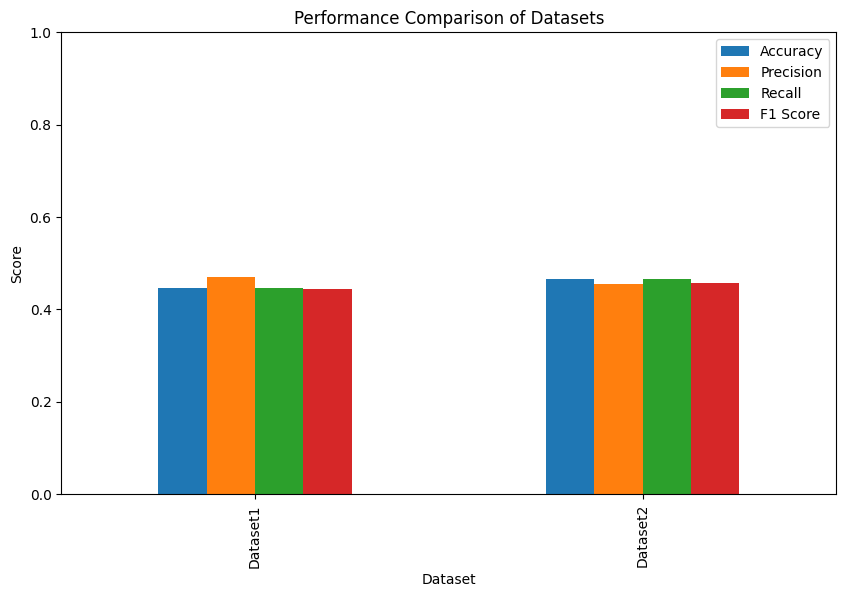

In [43]:
#Bar chart of metrics
results.plot(x='Dataset',y=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    kind='bar',figsize=(10,6))

plt.title("Performance Comparison of Datasets")
plt.ylabel("Score")
plt.xlabel("Dataset")
plt.ylim(0,1)

plt.show()

In [33]:
#Feature importance

importance1 = pd.DataFrame({'Feature': X1.columns,'Importance': model1.feature_importances_})
importance1 = importance1.sort_values(by='Importance',ascending=False)

importance2 = pd.DataFrame({'Feature': X2.columns,'Importance': model2.feature_importances_})
importance2 = importance2.sort_values(by='Importance',ascending=False)

print("\nDataset 1 Feature Importance:\n")
print(importance1)

print("\nDataset 2 Feature Importance:\n")
print(importance2)




Dataset 1 Feature Importance:

         Feature  Importance
3   Release_Year    0.362616
1   Platform_enc    0.344591
0      Genre_enc    0.277057
2  Publisher_enc    0.015736

Dataset 2 Feature Importance:

         Feature  Importance
2  Publisher_enc    0.523655
1   Platform_enc    0.303163
0      Genre_enc    0.173182
3   Release_Year    0.000000


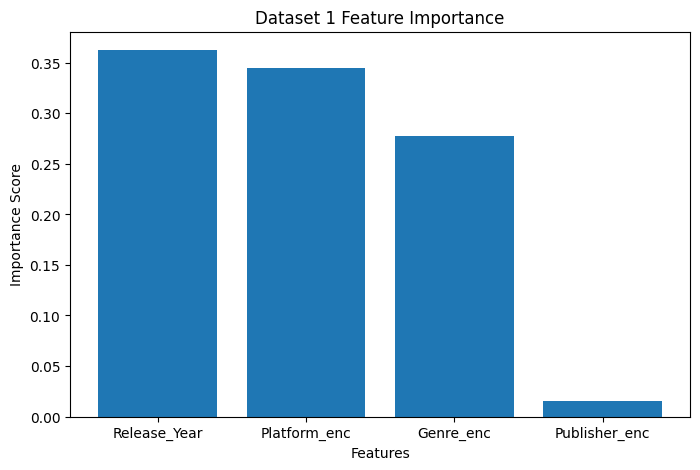

In [34]:
#Importance graph of Dataset1
plt.figure(figsize=(8,5))

plt.bar(importance1['Feature'],importance1['Importance'])
plt.title('Dataset 1 Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.show()